# Background Sampling Sensitivity Analysis

Plots 1-a, 1-b, 2-a for the background sampling experiment.
Set `DATASET` below to switch datasets. All three metrics (RBO, Jaccard, L2) shown per figure.

In [1]:
# ════════════════════════════════════════════════════════════
#  CONFIG — change DATASET here
# ════════════════════════════════════════════════════════════
DATASET = 'gmsc'       # german | diabetes | acs | gmsc

# Jaccard k: fixed at 3
JAC_K_OVERRIDE = 3

In [ ]:
import os, pickle, itertools, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import StratifiedKFold
import scienceplots

from plot_violin import (
    compute_rbo_distance, compute_jaccard_distance, compute_l2_distance,
    compute_rbo_baseline, compute_jaccard_baseline, compute_l2_baseline,
)
from utils import load_data, set_global_seed

plt.style.use(['science', 'no-latex'])
matplotlib.rcParams.update({
    'font.size':        14,
    'axes.labelsize':   16,
    'axes.titlesize':   16,
    'xtick.labelsize':  15,
    'ytick.labelsize':  15,
    'legend.fontsize':  14,
    'figure.titlesize': 17,
    'savefig.bbox':     'standard',   # override scienceplots' tight default
})

MODELS  = ['dt', 'rf', 'xgb', 'mlp', 'ftt']
METHODS = ['random', 'kmeans', 'pred_stratified', 'cte']
METHOD_LABELS = {'random': 'Random', 'kmeans': 'KMeans',
                 'pred_stratified': 'Pred-Strat', 'cte': 'CTE'}
MODEL_LABELS  = {'dt': 'DT', 'rf': 'RF', 'xgb': 'XGB', 'mlp': 'MLP', 'ftt': 'FTT'}

MODEL_SEEDS = [0, 21, 42, 63, 84]
N_BG_SEEDS  = 5
N_CHUNKS    = {'german': 1, 'diabetes': 1, 'acs': 100, 'gmsc': 100}
N_FEATS     = {'german': 16, 'diabetes': 8, 'acs': 8, 'gmsc': 10}

RES_DIR   = 'results_tree'
PROBA_DIR = os.path.join('proba', 'proba')
FIG_DIR   = 'figures_bg'
os.makedirs(FIG_DIR, exist_ok=True)

MODEL_COLORS = {'dt': '#e07b39', 'rf': '#3a9e5f', 'xgb': '#c94040',
                'mlp': '#4f78c6', 'ftt': '#9b6abf'}

# 1-c / 1-d: explainer comparison (blue vs pink)
EXPL_A_COLOR = '#5B9BD5'   # blue  — KernelSHAP
EXPL_B_COLOR = '#E87070'   # pink  — PermutationSHAP

# 1-b only: variance source (teal vs orange — distinct from blue/pink above)
BG_SEED_COLOR  = '#52A788'  # teal-green — BG Seed
MOD_SEED_COLOR = '#D4824E'  # warm orange — Model Seed

METRICS = ['l2', 'jac', 'rbo']
METRIC_LABELS = {'l2': 'L2 Distance', 'jac': 'Top-3 Jaccard Distance', 'rbo': '1-RBO'}

def jac_k():
    return JAC_K_OVERRIDE if JAC_K_OVERRIDE is not None else N_FEATS[DATASET]

print(f'Dataset: {DATASET}  |  Jaccard k: {jac_k()}')

In [3]:
# ── Data loading ──────────────────────────────────────────────────────────────

def load_sv(model, model_seed, method, s_idx, explainer='kernel_shap'):
    prefix = 'perm_' if explainer == 'permutation_shap' else ''
    n_ch   = N_CHUNKS[DATASET]

    def _chunk(c=None):
        base = f'{DATASET}_{model}_0_{model_seed}_{prefix}{method}_s{s_idx}'
        fn   = f'{base}_c{c}_sv.pkl' if c is not None else f'{base}_sv.pkl'
        p    = os.path.join(RES_DIR, fn)
        if not os.path.exists(p): return None
        with open(p, 'rb') as f: obj = pickle.load(f)
        return obj.values

    if n_ch == 1:
        return _chunk()
    arrs = [_chunk(c) for c in range(n_ch)]
    arrs = [a for a in arrs if a is not None]
    return np.concatenate(arrs, axis=0) if arrs else None


# ── Pairwise distances for all metrics ───────────────────────────────────────

def dist_fn(metric, v1, v2):
    if metric == 'rbo': return compute_rbo_distance(v1, v2)
    if metric == 'jac': return compute_jaccard_distance(v1, v2, k=jac_k())
    if metric == 'l2':  return compute_l2_distance(v1, v2)


PAIRS_5 = list(itertools.combinations(range(5), 2))  # 10 pairs

# pw_bg[model][method][metric]   = (10*N,) array  — kernel_shap, BG seed pairs
# pw_mod[model][method][metric]  = (10*N,) array  — kernel_shap, model seed pairs
# inst_bg[model][method][metric] = (N,) per-instance mean
pw_bg   = {m: {me: {mt: np.array([]) for mt in METRICS} for me in METHODS} for m in MODELS}
pw_mod  = {m: {me: {mt: np.array([]) for mt in METRICS} for me in METHODS} for m in MODELS}
inst_bg = {m: {me: {mt: np.array([]) for mt in METRICS} for me in METHODS} for m in MODELS}

for model in MODELS:
    for method in METHODS:
        bg_list  = [load_sv(model, 0,  method, s) for s in range(N_BG_SEEDS)]
        bg_list  = [a for a in bg_list if a is not None]
        mod_list = [load_sv(model, ms, method, 0) for ms in MODEL_SEEDS]
        mod_list = [a for a in mod_list if a is not None]

        for metric in METRICS:
            # BG pairs
            rows, inst_rows = [], []
            for i, j in PAIRS_5:
                if i >= len(bg_list) or j >= len(bg_list): continue
                n = min(len(bg_list[i]), len(bg_list[j]))
                d = dist_fn(metric, bg_list[i][:n], bg_list[j][:n])
                rows.append(d); inst_rows.append(d)
            if rows:
                pw_bg[model][method][metric]   = np.concatenate(rows)
                inst_bg[model][method][metric] = np.stack(inst_rows).mean(axis=0)

            # Model seed pairs
            rows = []
            for i, j in PAIRS_5:
                if i >= len(mod_list) or j >= len(mod_list): continue
                n = min(len(mod_list[i]), len(mod_list[j]))
                d = dist_fn(metric, mod_list[i][:n], mod_list[j][:n])
                rows.append(d)
            if rows:
                pw_mod[model][method][metric] = np.concatenate(rows)

    print(f'{DATASET}/{model}: loaded')

print('Done.')

gmsc/dt: loaded
gmsc/rf: loaded
gmsc/xgb: loaded
gmsc/mlp: loaded
gmsc/ftt: loaded
Done.


In [4]:
# ── Baselines ─────────────────────────────────────────────────────────────────
d = N_FEATS[DATASET]
k = jac_k()
r = max(1, d // 3)   # top-r for L2 baseline (concentrated features)

bl = {
    'rbo': compute_rbo_baseline(n_features=d),
    'jac': compute_jaccard_baseline(d=d, r=k),
    'l2':  compute_l2_baseline(d=d, r=r),
}
for mt in METRICS:
    print(f'{mt}: [{bl[mt]["min"]:.4f}, {bl[mt]["max"]:.4f}]')

l2: [0.1250, 0.2138]
jac: [0.3008, 0.5034]
rbo: [0.4752, 0.5562]


In [5]:
# ── Plot helpers ──────────────────────────────────────────────────────────────

def styled_violin(ax, data_list, positions, colors, widths=0.35, alpha=0.75):
    if not data_list: return None
    parts = ax.violinplot(data_list, positions=positions, widths=widths,
                          showmedians=True, showextrema=False)
    for pc, c in zip(parts['bodies'], colors):
        pc.set_facecolor(c); pc.set_edgecolor('none'); pc.set_alpha(alpha)
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(1.5)
    parts['cmedians'].set_zorder(5)
    return parts


def add_baseline(ax, metric):
    lo, hi = bl[metric]['min'], bl[metric]['max']
    ax.axhspan(lo, hi, alpha=0.15, color='red', zorder=0)
    ax.axhline(lo, linestyle='--', color='red', linewidth=1.2, alpha=0.5, zorder=0)
    ax.axhline(hi, linestyle='--', color='red', linewidth=1.2, alpha=0.5, zorder=0)
    return mpatches.Patch(facecolor='red', alpha=0.3, label='Baseline Range')


def set_ax(ax, metric, xtick_labels, ylim=None, xlabel='Model'):
    ax.set_xticks(range(len(xtick_labels)))
    ax.set_xticklabels(xtick_labels, fontsize=15)
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=16)
    ax.set_xlabel(xlabel, fontsize=16)
    if ylim: ax.set_ylim(*ylim)
    ax.tick_params(axis='both', labelsize=15, length=0)


print('Helpers ready.')

Helpers ready.


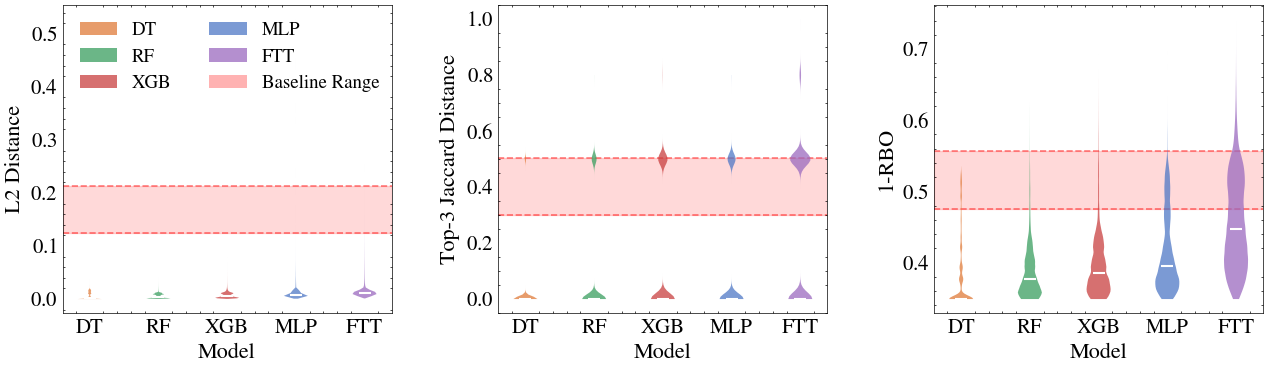

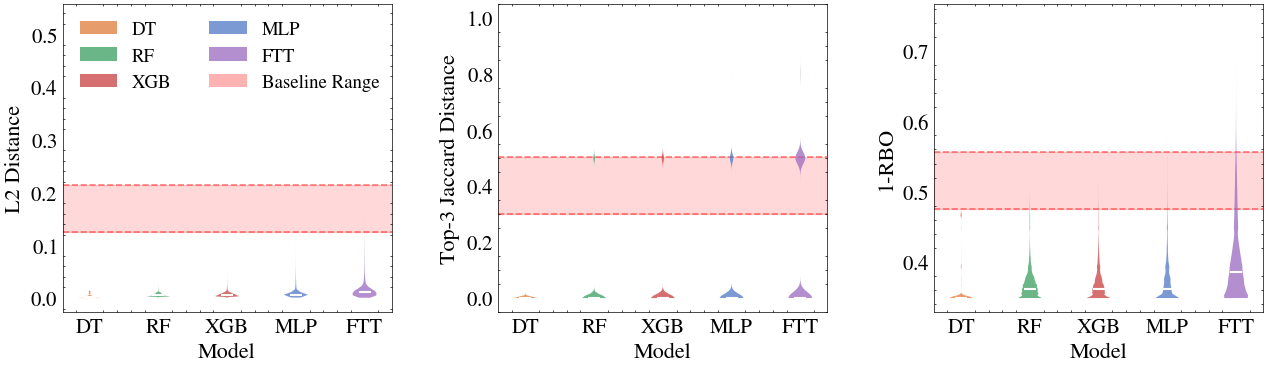

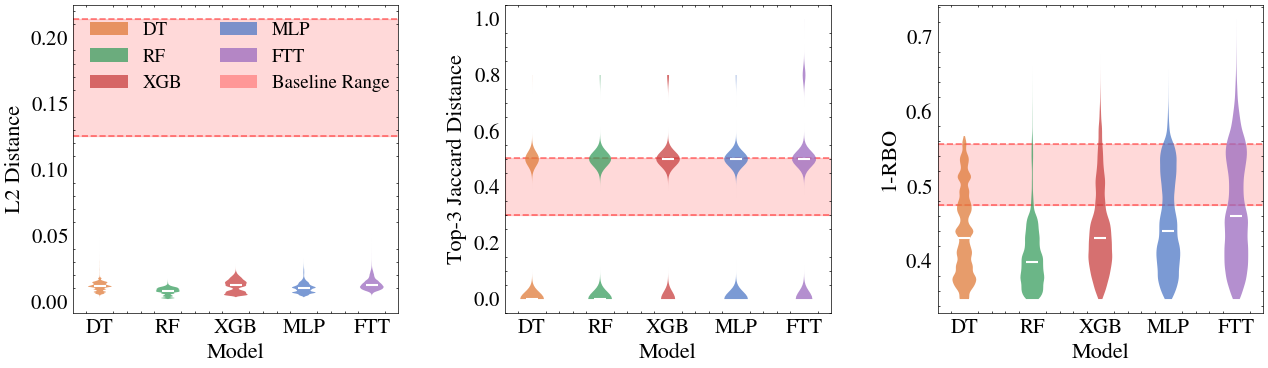

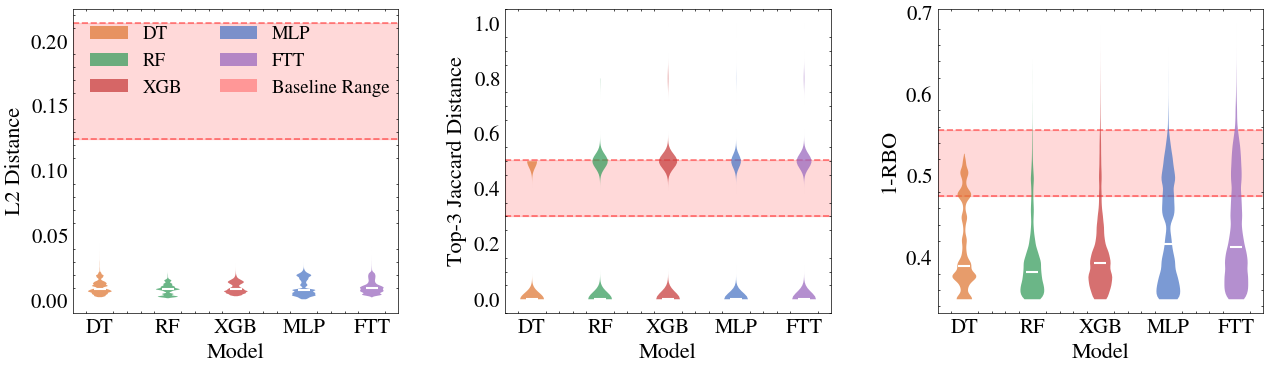

In [6]:
# ── Figure 1-a: Overall pooled sensitivity (BG + Model pairs) ─────────────────
# One figure per method, 3 subplots (RBO | Jaccard | L2).

for method in METHODS:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

    for ax, metric in zip(axes, METRICS):
        data_list, colors = [], []
        for model in MODELS:
            bg_d  = pw_bg[model][method][metric]
            mod_d = pw_mod[model][method][metric]
            parts = [x for x in [bg_d, mod_d] if len(x)]
            if not parts: continue
            data_list.append(np.concatenate(parts))
            colors.append(MODEL_COLORS[model])

        positions = list(range(len(data_list)))
        styled_violin(ax, data_list, positions, colors)
        bl_patch = add_baseline(ax, metric)
        set_ax(ax, metric, [MODEL_LABELS[m] for m in MODELS[:len(data_list)]])

    handles = [mpatches.Patch(facecolor=MODEL_COLORS[m], alpha=0.75, label=MODEL_LABELS[m])
               for m in MODELS] + [bl_patch]
    axes[0].legend(handles=handles, fontsize=13.5, ncol=2, loc='upper left')

    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f'1a_{DATASET}_{method}.pdf'), bbox_inches='tight')
    plt.show(); plt.close(fig)

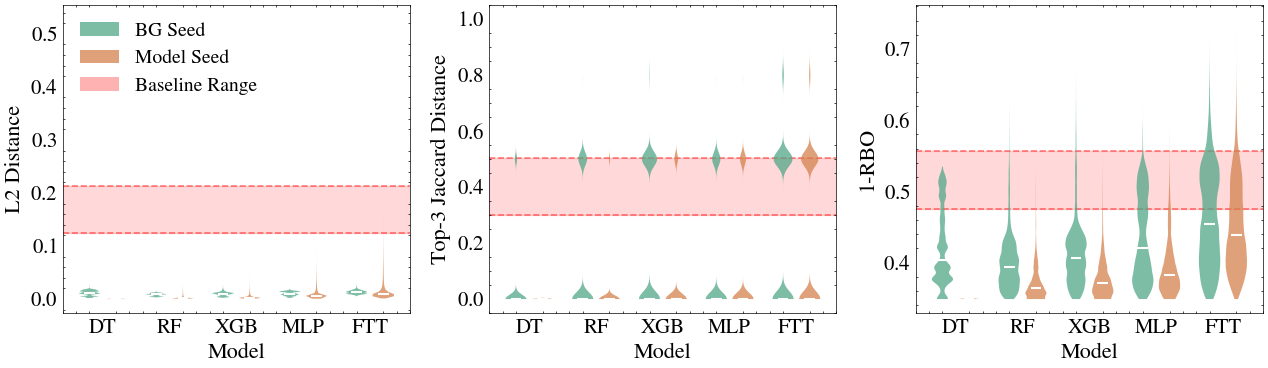

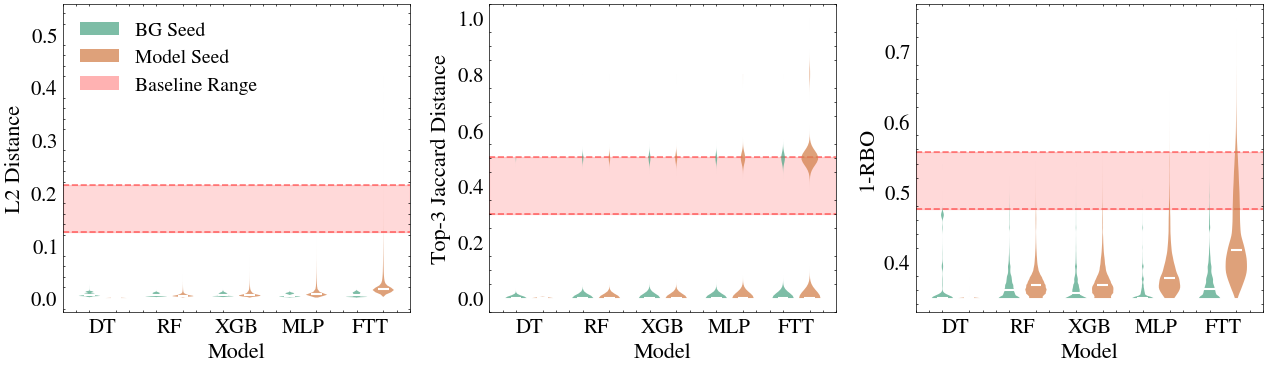

In [7]:
# ── Figure 1-b: BG Seed vs Model Seed sensitivity (random & kmeans only) ──────
# One figure per method, 3 subplots. Paired violins per model.
# Colors: teal (BG Seed) / orange (Model Seed) — distinct from 1-c/1-d blue/pink.

OFFSET = 0.20

for method in ['random', 'kmeans']:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

    for ax, metric in zip(axes, METRICS):
        bg_data, mod_data = [], []
        bg_pos, mod_pos   = [], []
        valid_models = []

        for xi, model in enumerate(MODELS):
            bg_d  = pw_bg[model][method][metric]
            mod_d = pw_mod[model][method][metric]
            if not len(bg_d) and not len(mod_d): continue
            valid_models.append(model)
            if len(bg_d):  bg_data.append(bg_d);   bg_pos.append(xi - OFFSET)
            if len(mod_d): mod_data.append(mod_d); mod_pos.append(xi + OFFSET)

        if bg_data:  styled_violin(ax, bg_data,  bg_pos,  [BG_SEED_COLOR]  * len(bg_data),  widths=0.32)
        if mod_data: styled_violin(ax, mod_data, mod_pos, [MOD_SEED_COLOR] * len(mod_data), widths=0.32)

        bl_patch = add_baseline(ax, metric)
        set_ax(ax, metric, [MODEL_LABELS[m] for m in valid_models])
        ax.set_xlim(-0.6, len(valid_models) - 0.4)

    bg_patch  = mpatches.Patch(facecolor=BG_SEED_COLOR,  alpha=0.75, label='BG Seed')
    mod_patch = mpatches.Patch(facecolor=MOD_SEED_COLOR, alpha=0.75, label='Model Seed')
    axes[0].legend(handles=[bg_patch, mod_patch, bl_patch], fontsize=14, loc='upper left')

    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f'1b_{DATASET}_{method}.pdf'), bbox_inches='tight')
    plt.show(); plt.close(fig)

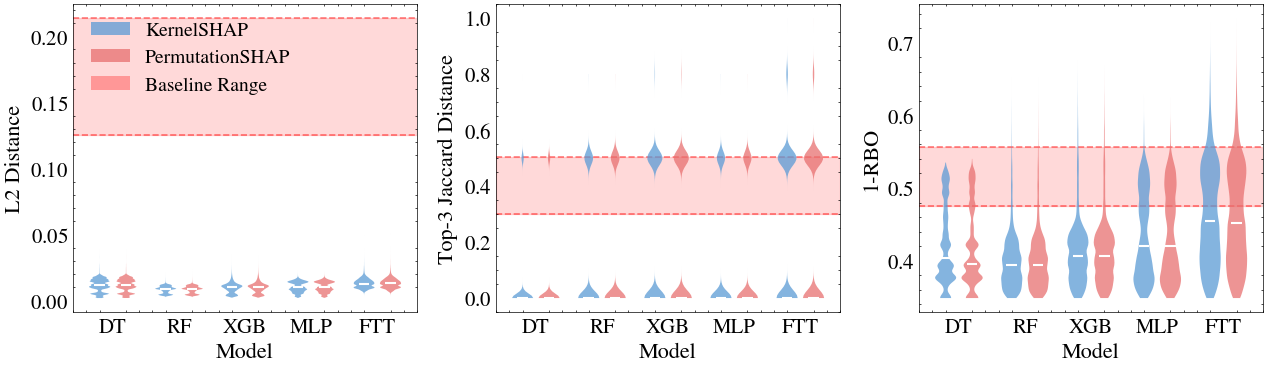

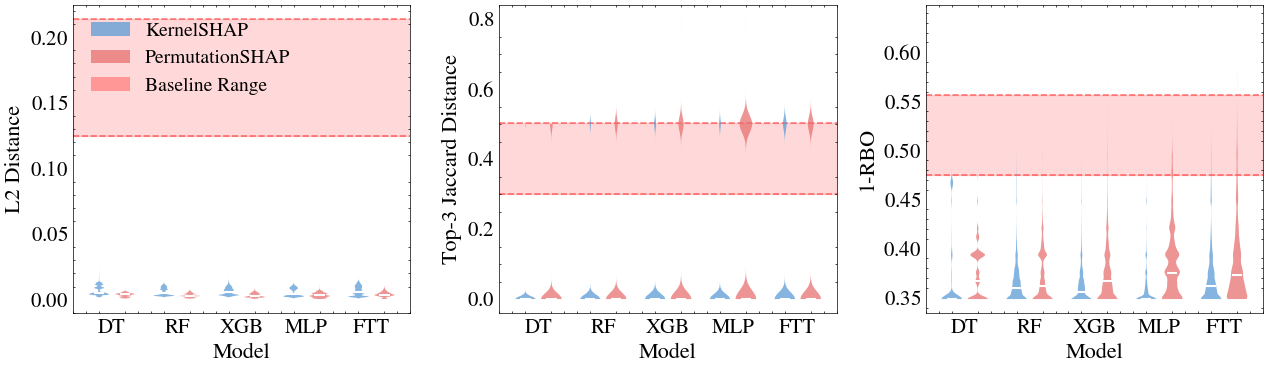

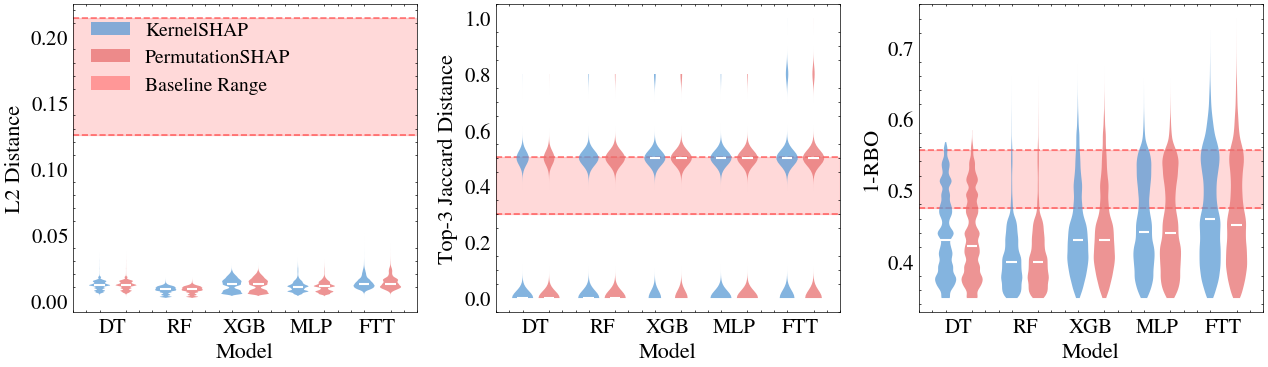

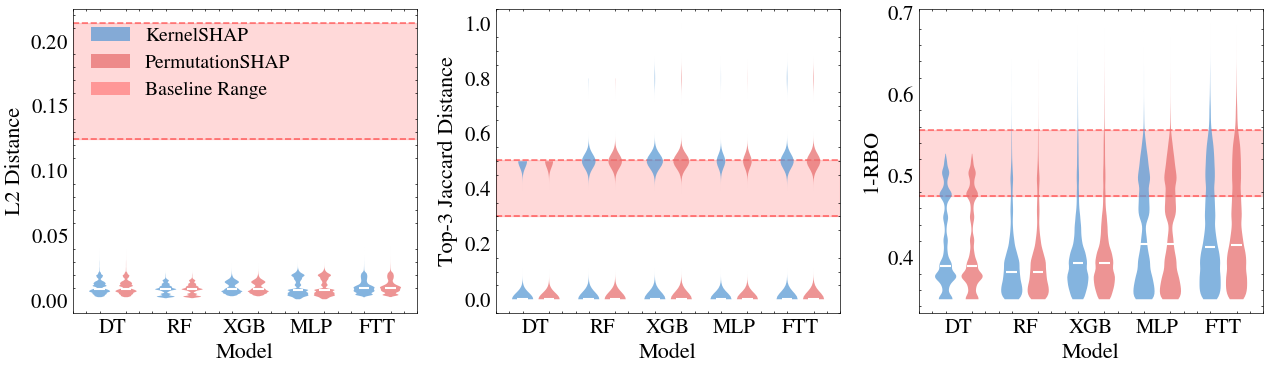

In [8]:
# ── Figure 1-c: KernelSHAP vs PermutationSHAP, per method (4 figures) ─────────
# One figure per sampling method, 3 subplots (L2 | Jac | RBO).
# x-axis = model, blue = KernelSHAP, pink = PermutationSHAP.
# Data: BG seed pairs C(5,2)=10 per method.

for method in METHODS:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

    for ax, metric in zip(axes, METRICS):
        kern_data, perm_data = [], []
        valid_xi = []

        for xi, model in enumerate(MODELS):
            bg_k = [load_sv(model, 0, method, s, 'kernel_shap')      for s in range(N_BG_SEEDS)]
            bg_p = [load_sv(model, 0, method, s, 'permutation_shap') for s in range(N_BG_SEEDS)]
            bg_k = [a for a in bg_k if a is not None]
            bg_p = [a for a in bg_p if a is not None]

            kern_rows, perm_rows = [], []
            for i, j in PAIRS_5:
                if i < len(bg_k) and j < len(bg_k):
                    n = min(len(bg_k[i]), len(bg_k[j]))
                    kern_rows.append(dist_fn(metric, bg_k[i][:n], bg_k[j][:n]))
                if i < len(bg_p) and j < len(bg_p):
                    n = min(len(bg_p[i]), len(bg_p[j]))
                    perm_rows.append(dist_fn(metric, bg_p[i][:n], bg_p[j][:n]))

            k_arr = np.concatenate(kern_rows) if kern_rows else np.array([])
            p_arr = np.concatenate(perm_rows) if perm_rows else np.array([])
            if len(k_arr) or len(p_arr):
                valid_xi.append(xi)
                kern_data.append(k_arr)
                perm_data.append(p_arr)

        k_nonempty = [(d, xi) for d, xi in zip(kern_data, valid_xi) if len(d)]
        p_nonempty = [(d, xi) for d, xi in zip(perm_data, valid_xi) if len(d)]

        if k_nonempty:
            styled_violin(ax, [d for d, _ in k_nonempty],
                          [xi - OFFSET for _, xi in k_nonempty],
                          [EXPL_A_COLOR] * len(k_nonempty), widths=0.32)
        if p_nonempty:
            styled_violin(ax, [d for d, _ in p_nonempty],
                          [xi + OFFSET for _, xi in p_nonempty],
                          [EXPL_B_COLOR] * len(p_nonempty), widths=0.32)

        bl_patch = add_baseline(ax, metric)
        set_ax(ax, metric, [MODEL_LABELS[MODELS[xi]] for xi in valid_xi])
        ax.set_xticks(valid_xi)
        ax.set_xticklabels([MODEL_LABELS[MODELS[xi]] for xi in valid_xi], fontsize=15)
        ax.set_xlim(-0.6, len(MODELS) - 0.4)

    kern_patch = mpatches.Patch(facecolor=EXPL_A_COLOR, alpha=0.75, label='KernelSHAP')
    perm_patch = mpatches.Patch(facecolor=EXPL_B_COLOR, alpha=0.75, label='PermutationSHAP')
    axes[0].legend(handles=[kern_patch, perm_patch, bl_patch], fontsize=14, loc='upper left')

    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f'1c_{DATASET}_{method}.pdf'), bbox_inches='tight')
    plt.show(); plt.close(fig)

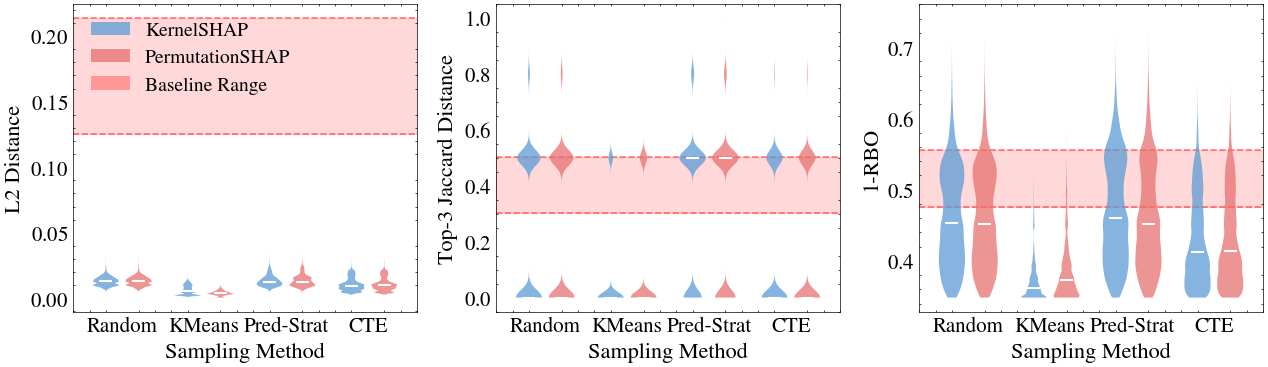

In [9]:
# ── Figure 1-d: KernelSHAP vs PermutationSHAP, ftt fixed, per sampling method ─
# x-axis = sampling method, blue violin = KernelSHAP, pink violin = PermutationSHAP
# Data: BG seed pairs C(5,2)=10, model=ftt fixed

FTT_MODEL = 'ftt'

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, metric in zip(axes, METRICS):
    kern_data, perm_data = [], []
    valid_xi = []

    for xi, method in enumerate(METHODS):
        bg_k = [load_sv(FTT_MODEL, 0, method, s, 'kernel_shap')      for s in range(N_BG_SEEDS)]
        bg_p = [load_sv(FTT_MODEL, 0, method, s, 'permutation_shap') for s in range(N_BG_SEEDS)]
        bg_k = [a for a in bg_k if a is not None]
        bg_p = [a for a in bg_p if a is not None]

        kern_rows, perm_rows = [], []
        for i, j in PAIRS_5:
            if i < len(bg_k) and j < len(bg_k):
                n = min(len(bg_k[i]), len(bg_k[j]))
                kern_rows.append(dist_fn(metric, bg_k[i][:n], bg_k[j][:n]))
            if i < len(bg_p) and j < len(bg_p):
                n = min(len(bg_p[i]), len(bg_p[j]))
                perm_rows.append(dist_fn(metric, bg_p[i][:n], bg_p[j][:n]))

        k_arr = np.concatenate(kern_rows) if kern_rows else np.array([])
        p_arr = np.concatenate(perm_rows) if perm_rows else np.array([])
        if len(k_arr) or len(p_arr):
            valid_xi.append(xi)
            kern_data.append(k_arr)
            perm_data.append(p_arr)

    k_nonempty = [(d, xi) for d, xi in zip(kern_data, valid_xi) if len(d)]
    p_nonempty = [(d, xi) for d, xi in zip(perm_data, valid_xi) if len(d)]

    if k_nonempty:
        styled_violin(ax, [d for d, _ in k_nonempty],
                      [xi - OFFSET for _, xi in k_nonempty],
                      [EXPL_A_COLOR] * len(k_nonempty), widths=0.32)
    if p_nonempty:
        styled_violin(ax, [d for d, _ in p_nonempty],
                      [xi + OFFSET for _, xi in p_nonempty],
                      [EXPL_B_COLOR] * len(p_nonempty), widths=0.32)

    bl_patch = add_baseline(ax, metric)
    set_ax(ax, metric, [METHOD_LABELS[METHODS[xi]] for xi in valid_xi], xlabel='Sampling Method')
    ax.set_xticks(valid_xi)
    ax.set_xticklabels([METHOD_LABELS[METHODS[xi]] for xi in valid_xi], fontsize=15)
    ax.set_xlim(-0.6, len(METHODS) - 0.4)

kern_patch = mpatches.Patch(facecolor=EXPL_A_COLOR, alpha=0.75, label='KernelSHAP')
perm_patch = mpatches.Patch(facecolor=EXPL_B_COLOR, alpha=0.75, label='PermutationSHAP')
axes[0].legend(handles=[kern_patch, perm_patch, bl_patch], fontsize=14, loc='upper left')

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f'1d_{DATASET}.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)

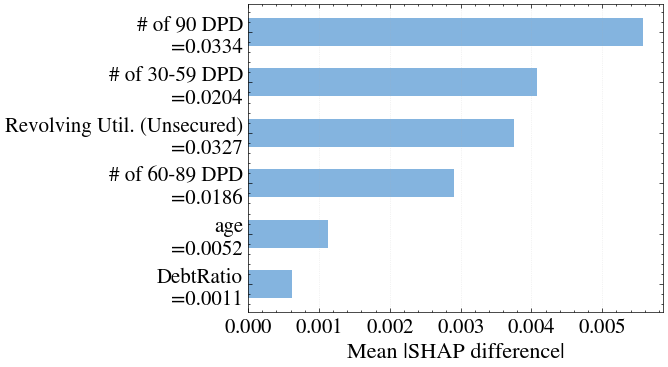

Saved: figures_bg/feat_gmsc_dt.pdf


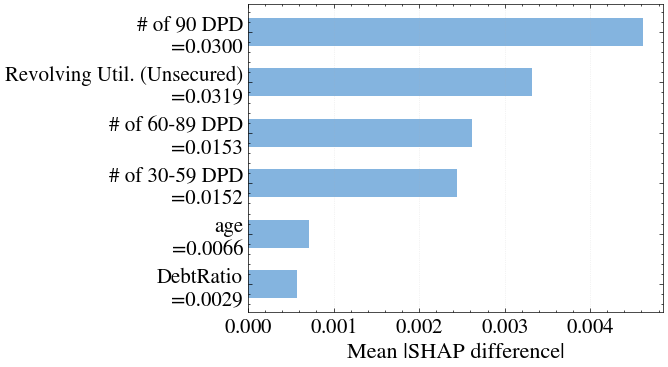

Saved: figures_bg/feat_gmsc_rf.pdf


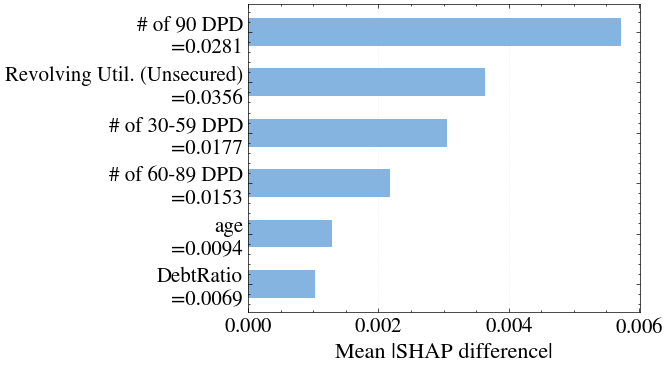

Saved: figures_bg/feat_gmsc_xgb.pdf


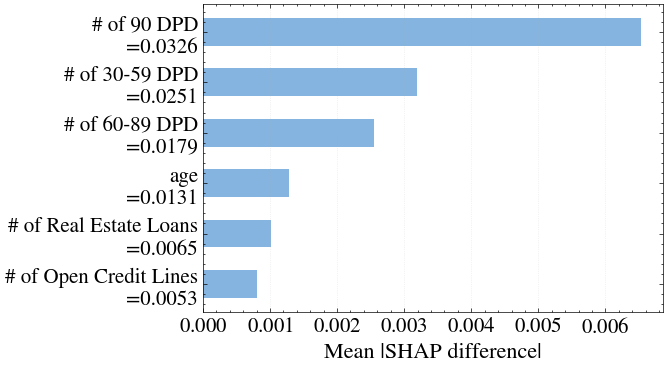

Saved: figures_bg/feat_gmsc_mlp.pdf


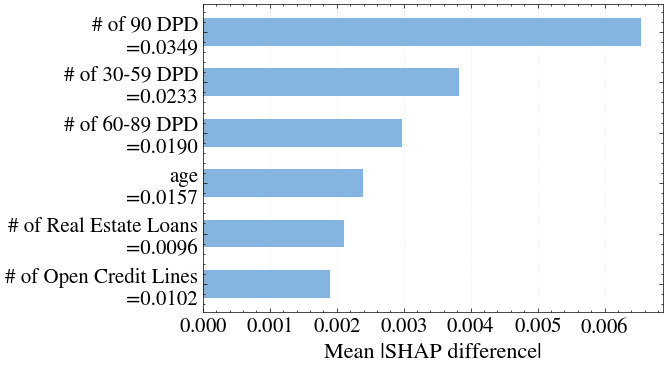

Saved: figures_bg/feat_gmsc_ftt.pdf


In [10]:
# ── Figure feature-wise: per-feature BG sensitivity (horizontal bar plot) ─────
# y=feature_name\n=mean|SHAP| (feature importance), sorted by mean|diff| descending
# x=mean |sv_i[:,f] - sv_j[:,f]| pooled across all methods & BG seed pairs
# One figure per model. Shows top 6 most sensitive features only.

TOP_N = 6

def _load_feat_names():
    for model in MODELS:
        for method in METHODS:
            n_ch = N_CHUNKS[DATASET]
            base = f'{DATASET}_{model}_0_0_{method}_s0'
            fp = os.path.join(RES_DIR, f'{base}_sv.pkl' if n_ch == 1 else f'{base}_c0_sv.pkl')
            if os.path.exists(fp):
                with open(fp, 'rb') as f: obj = pickle.load(f)
                return list(obj.feature_names) if obj.feature_names is not None else None
    return None

_FEAT_RENAME = {
    'RevolvingUtilizationOfUnsecuredLines': 'Revolving Util. (Unsecured)',
    'NumberOfTime30-59DaysPastDueNotWorse': '# of 30-59 DPD',
    'NumberOfOpenCreditLinesAndLoans':      '# of Open Credit Lines',
    'NumberOfTimes90DaysLate':              '# of 90 DPD',
    'NumberRealEstateLoansOrLines':         '# of Real Estate Loans',
    'NumberOfTime60-89DaysPastDueNotWorse': '# of 60-89 DPD',
}

def _rename_feat(name):
    return _FEAT_RENAME.get(name, name)

feat_names = _load_feat_names()

for model in MODELS:
    all_diffs = []
    all_shap  = []

    for method in METHODS:
        svs = [load_sv(model, 0, method, s) for s in range(N_BG_SEEDS)]
        svs = [a for a in svs if a is not None]
        for sv in svs:
            all_shap.append(np.abs(sv).mean(axis=0))   # (d,) — feature importance
        for i, j in PAIRS_5:
            if i >= len(svs) or j >= len(svs): continue
            n = min(len(svs[i]), len(svs[j]))
            all_diffs.append(np.abs(svs[i][:n] - svs[j][:n]))   # (n, d)

    if not all_diffs: continue
    D = np.concatenate(all_diffs, axis=0)   # (total, d)

    mean_diff = D.mean(axis=0)              # x-axis: sensitivity
    mean_shap = np.mean(all_shap, axis=0)   # label: feature importance

    # ascending sort → take last TOP_N (most sensitive) → top of barh
    order  = np.argsort(mean_diff)[-TOP_N:]
    labels = [
        f'{_rename_feat(feat_names[fi]) if feat_names else f"F{fi}"}\n={mean_shap[fi]:.4f}'
        for fi in order
    ]
    values = mean_diff[order]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(range(TOP_N), values, height=0.55, color=EXPL_A_COLOR, alpha=0.75)

    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(labels, fontsize=15)
    ax.set_xlabel('Mean |SHAP difference|', fontsize=16)
    ax.tick_params(axis='x', labelsize=15)
    ax.grid(axis='x', linestyle=':', alpha=0.3, linewidth=0.5)

    fig.subplots_adjust(left=0.42, right=0.97, bottom=0.14, top=0.97)
    fname = os.path.join(FIG_DIR, f'feat_{DATASET}_{model}.pdf')
    fig.savefig(fname)
    plt.show(); plt.close(fig)
    print(f'Saved: {fname}')

In [11]:
# ── Certainty masks ───────────────────────────────────────────────────────────
# Certain: P >= 0.9 or P <= 0.1  |  Uncertain: 0.4 <= P <= 0.6

cert_masks = {}
X, Y = load_data(DATASET)
set_global_seed(42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for i, (_, test_idx) in enumerate(skf.split(X, Y)):
    if i == 0: y_test = Y.iloc[test_idx].values; break

for model in MODELS:
    proba_path = os.path.join(PROBA_DIR, f'{DATASET}_{model}_0_0_proba.pkl')
    if not os.path.exists(proba_path):
        print(f'[SKIP] {proba_path}')
        cert_masks[model] = None; continue
    with open(proba_path, 'rb') as f:
        p = np.asarray(pickle.load(f)).ravel()
    cert_masks[model] = {
        'certain':   (p >= 0.9) | (p <= 0.1),
        'uncertain': (p >= 0.4) & (p <= 0.6),
    }
    c = cert_masks[model]
    print(f'{model}: certain={c["certain"].sum()} ({c["certain"].mean()*100:.1f}%)  '
          f'uncertain={c["uncertain"].sum()} ({c["uncertain"].mean()*100:.1f}%)')

dt: certain=7786 (86.5%)  uncertain=165 (1.8%)
rf: certain=7553 (83.9%)  uncertain=200 (2.2%)
xgb: certain=7496 (83.3%)  uncertain=191 (2.1%)
mlp: certain=7659 (85.1%)  uncertain=218 (2.4%)
ftt: certain=7545 (83.8%)  uncertain=211 (2.3%)


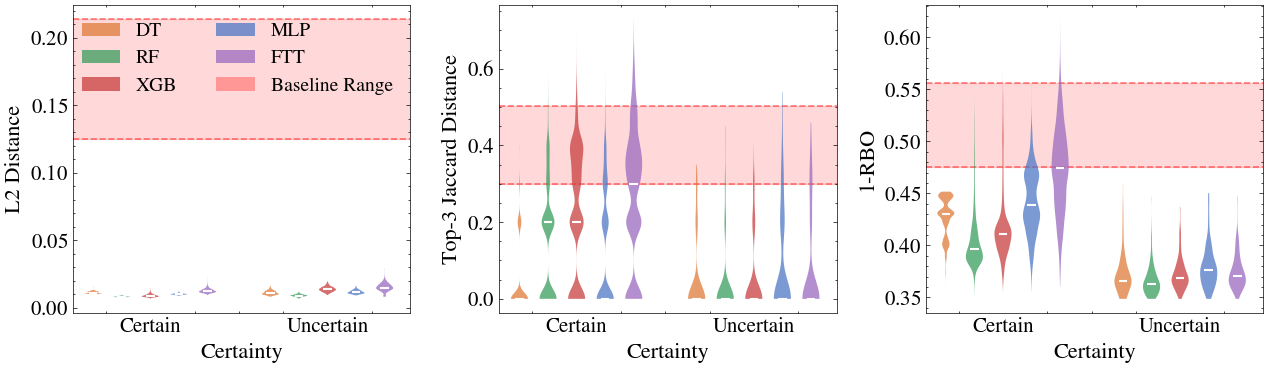

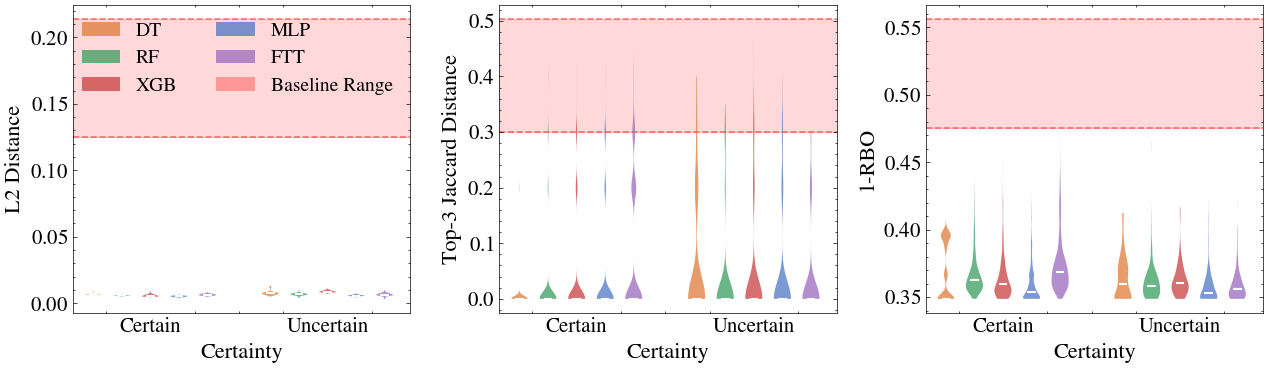

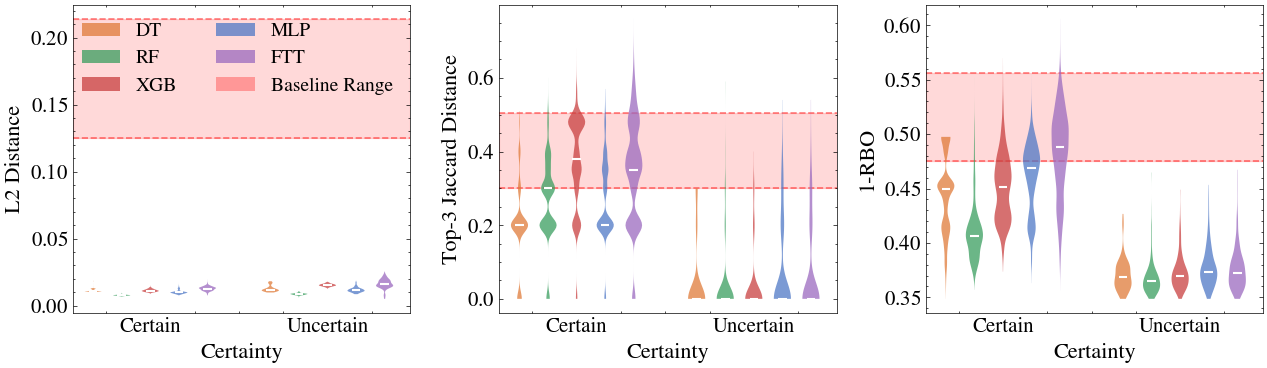

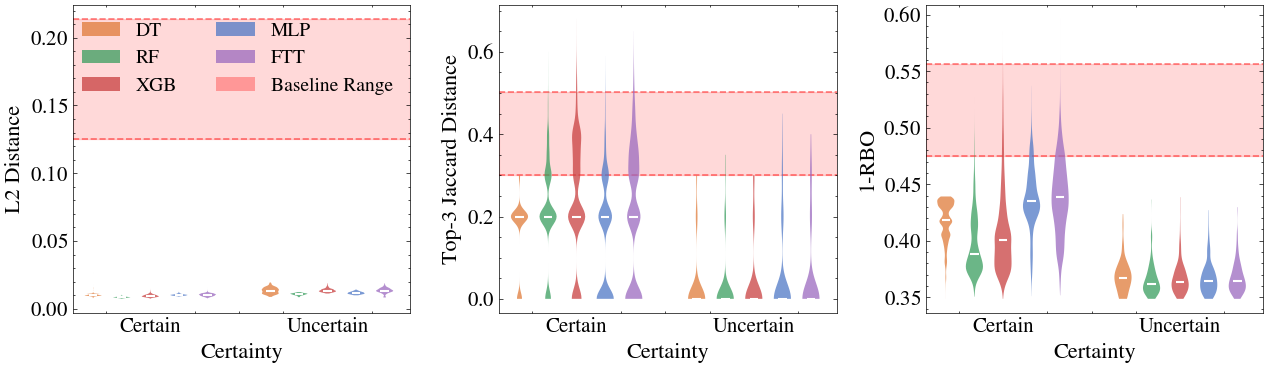

In [12]:
# ── Figure 2-a: Certainty-stratified sensitivity ──────────────────────────────
# One figure per method, 3 subplots (RBO | Jaccard | L2).
# Uses BG-seed pairs only; per-instance mean filtered by certainty mask.

GROUP_KEYS   = ['certain', 'uncertain']
GROUP_LABELS = ['Certain', 'Uncertain']
GROUP_GAP    = len(MODELS) + 1.2

for method in METHODS:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

    for ax, metric in zip(axes, METRICS):
        xtick_pos, xtick_lbl = [], []

        for gi, (grp_key, grp_lbl) in enumerate(zip(GROUP_KEYS, GROUP_LABELS)):
            x0 = gi * GROUP_GAP
            for mi, model in enumerate(MODELS):
                if cert_masks[model] is None: continue
                mask = cert_masks[model][grp_key]
                inst = inst_bg[model][method][metric]
                if not len(inst): continue
                n = min(len(inst), len(mask))
                filtered = inst[:n][mask[:n]]
                if not len(filtered): continue
                styled_violin(ax, [filtered], [x0 + mi], [MODEL_COLORS[model]], widths=0.6)

            center = x0 + (len(MODELS) - 1) / 2
            xtick_pos.append(center); xtick_lbl.append(grp_lbl)

        bl_patch = add_baseline(ax, metric)
        ax.set_xticks(xtick_pos)
        ax.set_xticklabels(xtick_lbl, fontsize=15)
        ax.set_xlim(-0.7, GROUP_GAP * 2 - 1.3)
        ax.set_ylabel(METRIC_LABELS[metric], fontsize=16)
        ax.set_xlabel('Certainty', fontsize=16)
        ax.tick_params(axis='y', labelsize=15)
        ax.tick_params(axis='x', length=0)

    handles = [mpatches.Patch(facecolor=MODEL_COLORS[m], alpha=0.75, label=MODEL_LABELS[m])
               for m in MODELS] + [bl_patch]
    axes[0].legend(handles=handles, fontsize=14, ncol=2, loc='upper right')

    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f'2a_{DATASET}_{method}.pdf'), bbox_inches='tight')
    plt.show(); plt.close(fig)